--- k-Nearest Neighbors Classification ---
Training: First 50 points labeled by rule (x<=0.5 -> Class1)

Results for k = 1:
Point x51 (value: 0.9044) is classified as Class2
Point x52 (value: 0.2857) is classified as Class1
Point x53 (value: 0.4267) is classified as Class1
Point x54 (value: 0.8303) is classified as Class2
Point x55 (value: 0.1052) is classified as Class1
Point x56 (value: 0.0529) is classified as Class1
Point x57 (value: 0.8459) is classified as Class2
Point x58 (value: 0.2692) is classified as Class1
Point x59 (value: 0.6596) is classified as Class2
Point x60 (value: 0.2027) is classified as Class1
Point x61 (value: 0.4119) is classified as Class1
Point x62 (value: 0.7025) is classified as Class2
Point x63 (value: 0.1223) is classified as Class1
Point x64 (value: 0.6117) is classified as Class2
Point x65 (value: 0.7830) is classified as Class2
Point x66 (value: 0.7470) is classified as Class2
Point x67 (value: 0.2194) is classified as Class1
Point x68 (value: 0.9486) 

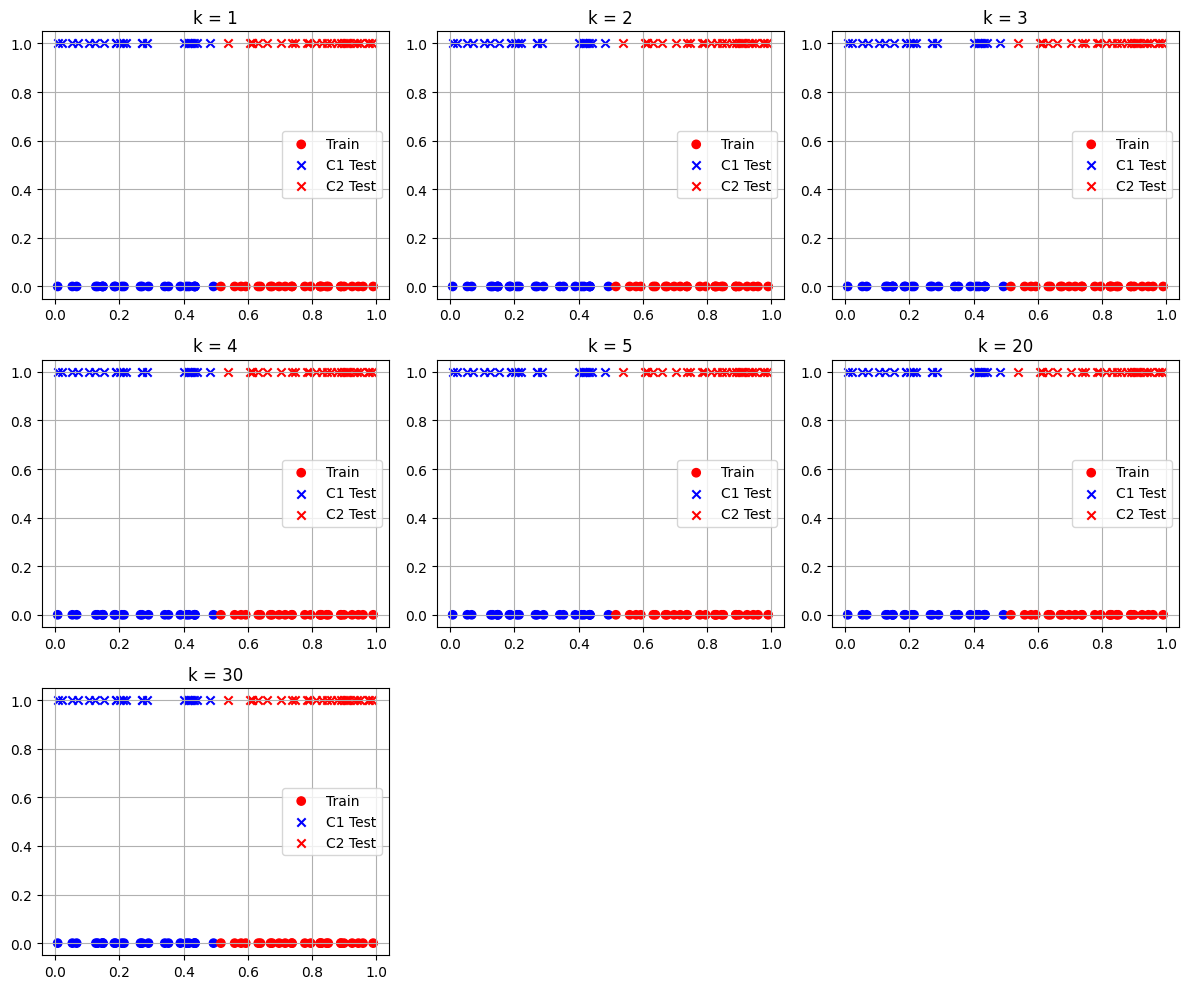

In [8]:
#lab5
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

data = np.random.rand(100)
train_data, test_data = data[:50], data[50:]
train_labels = ["Class1" if x <= 0.5 else "Class2" for x in train_data]

def knn(train_data, train_labels, test_point, k):
    d = sorted([(abs(test_point - train_data[i]), train_labels[i]) for i in range(len(train_data))])
    return Counter([label for _, label in d[:k]]).most_common(1)[0][0]

k_values = [1,2,3,4,5,20,30]

print("--- k-Nearest Neighbors Classification ---")
print("Training: First 50 points labeled by rule (x<=0.5 -> Class1)\n")

results = {}

for k in k_values:
    print(f"Results for k = {k}:")
    labels = [knn(train_data, train_labels, x, k) for x in test_data]
    results[k] = labels

    for i,(x,l) in enumerate(zip(test_data,labels),51):
        print(f"Point x{i} (value: {x:.4f}) is classified as {l}")
    print()

print("Classification complete.\n")

plt.figure(figsize=(12,10))

for i, (k, labels) in enumerate(results.items(), 1):
    c1 = [test_data[j] for j in range(len(test_data)) if labels[j] == "Class1"]
    c2 = [test_data[j] for j in range(len(test_data)) if labels[j] == "Class2"]

    plt.subplot(3,3,i)

    plt.scatter(train_data,[0]*50,
        c=["blue" if l=="Class1" else "red" for l in train_labels],
        label="Train")

    plt.scatter(c1,[1]*len(c1),c="blue",marker="x",label="C1 Test")
    plt.scatter(c2,[1]*len(c2),c="red",marker="x",label="C2 Test")

    plt.title(f"k = {k}")
    plt.grid(True)
    plt.legend()
plt.tight_layout()
plt.show()